# Final Project: Martine Maggi

Train a model to classify pulsars. :)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from psrqpy import QueryATNF
import jax
import jax.numpy as jnp
from clu import metrics
from flax.training import train_state
from flax import struct
import optax
from flax import linen as nn

So the bulk of those low PPdot dudes are MSPs and one weirdo hanging out with the CPs. The line sof division between MSPs, CPs, and Magnetars are pretty clear.

Options available to train a classifier:
- DNN
- ML
- Logistical Regression (which was kind of my first idea)
    - we used LogReg to say if something is in data or out, We used it with SDSS data to look at all SDSS data and say okay is this a quasar or not?

## Classification, Visualization, & Cleaning

In [2]:
# Bringing All Data loading into one place to clena this up

# Load in ATNF data

query = QueryATNF(params=['Name','P0','P1','PSRJ','Age','Edot', 'BSurf'])
psrs = query.pandas
psrs.head()

,PSRJ,P0_ERR,NAME,AGE,P0,EDOT,P1,P1_ERR,BSURF
0,J0002+6216,1.330875e-12,J0002+6216,3.063207e+05,0.115364,1.534306e+35,5.967033e-15,6.654376e-20,8.395828e+11
1,J0006+1834,1.400000e-10,J0006+1834,5.241664e+06,0.693748,2.479440e+32,2.097000e-15,1.200000e-17,1.220534e+12
2,J0007+7303,2.993276e-10,J0007+7303,1.388691e+04,0.315873,4.514345e+35,3.603905e-13,4.988794e-17,1.079675e+13
3,J0011+08,NaN,J0011+08,NaN,2.552870,NaN,NaN,NaN,NaN
4,J0012+5431,1.830489e-10,J0012+5431,3.740843e+08,3.025301,1.826919e+29,1.281342e-16,NaN,6.300381e+11


The P−Ṗ diagram showing the current sample of radio pulsars. Binary pulsars are highlighted by open circles. Lines of constant magnetic field (dashed), characteristic age (dash-dotted) and spin-down energy loss rate (dotted) are also shown.

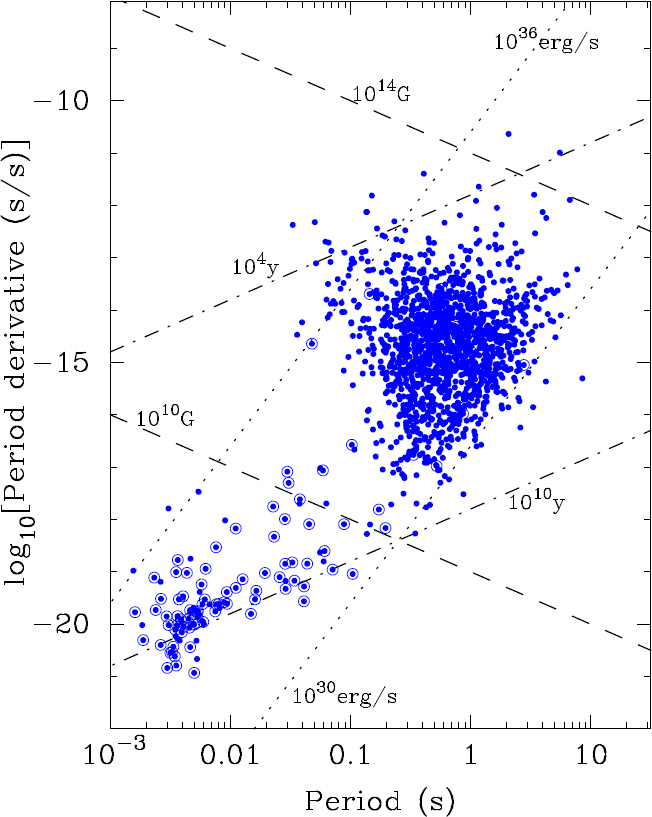

Source: https://pmc.ncbi.nlm.nih.gov/articles/PMC5256074/


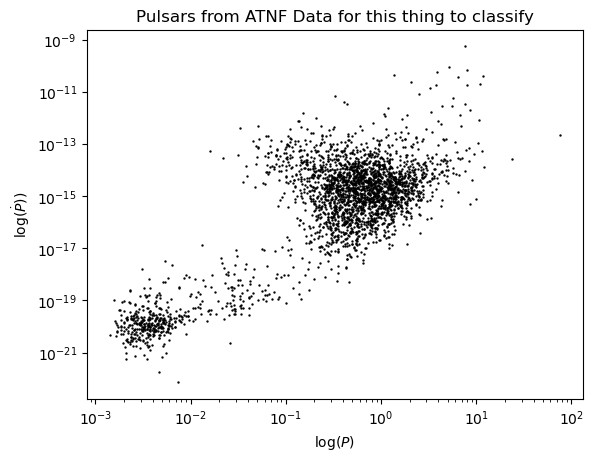

In [3]:
fig = plt.figure()
ax = plt.gca()
ax.scatter(psrs.P0, psrs.P1, s=0.5, color='black')
ax.set_yscale('log')
ax.set_xscale('log')
ax.set_xlabel(r'$\log(P)$')
ax.set_ylabel(r'$\log(\dot{P}))$')
ax.set_title('Pulsars from ATNF Data for this thing to classify');

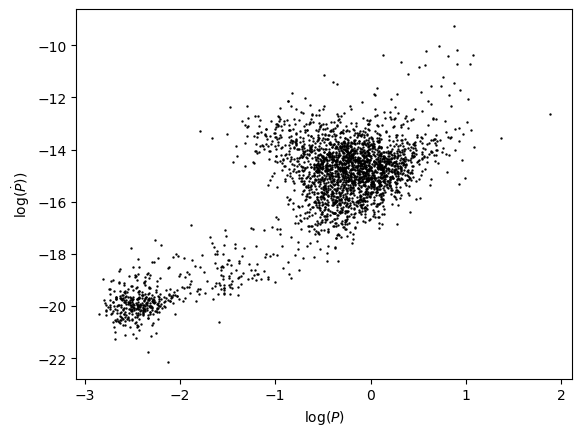

In [34]:
psrs_log_P0 = np.log10(psrs.P0)
psrs_log_P1 = np.log10(psrs.P1)

plt.scatter(psrs_log_P0, psrs_log_P1, s=0.5, color='black')
plt.xlabel(r'$\log(P)$')
plt.ylabel(r'$\log(\dot{P}))$')
plt.show()

In [35]:
psrs['logP0'] = np.log10(psrs['P0'])
psrs['logP1'] = np.log10(np.abs(psrs['P1']))   # P1 sometimes negative


Number of MSPs: (317,)


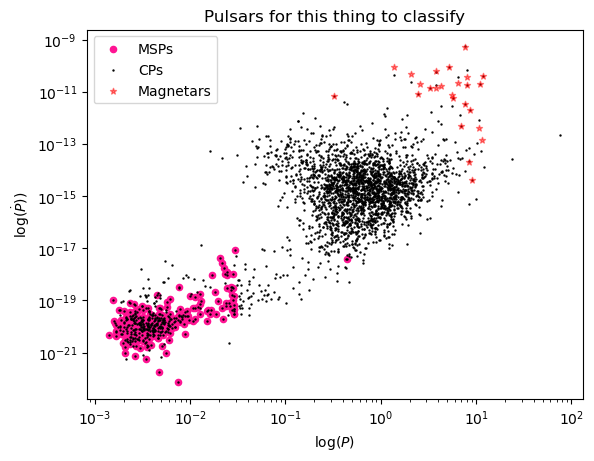

In [36]:
# Adding in Magnetars from McGill Database

mag_names=['Name','Period', 'Period_Err', 'Pdot', 'Pdot_Err']
mags = pd.read_csv('magnetars_Cat.csv', usecols=mag_names)

# Adding in MSPs from Lorimer Database

msp_cat_url = "https://pages.astro.umd.edu/~eferrara/pulsars/GalacticMSPs.txt"

msps_cols = ['NAME', 'P', 'DM', 'l', 'b', 'Pb', 'x', 'Discovery year', 'Notes']
msps = pd.read_csv(msp_cat_url, sep='\\s+', comment='#', names=msps_cols)

# Plot it all Together

##### You will note that I am not actually plotting the pulsars in Lorimer's Catalouge 
##### but selecting that ATNF pulsars that are ALSO in Lorimer's Catalouge.
##### This is because Lorimer's Catalouge does nto have a period derivative column OR
##### OR a time column to calculate the period derivative with. The ATNF has every pulsar anyway so we can use it
##### and just select out the MSP's with confidence.

psrs_msp = psrs['NAME'].isin(msps['NAME'])

print(f'Number of MSPs: {psrs.P0[psrs_msp].shape}')

fig = plt.figure()
ax = plt.gca()
ax.scatter(psrs.P0[psrs_msp], psrs.P1[psrs_msp], s=20, color='deeppink', label='MSPs')
ax.scatter(psrs.P0, psrs.P1, s=0.5, color='black', label='CPs')
ax.scatter(mags.Period, mags.Pdot, s=20, alpha=0.5, color='red', marker='*', label='Magnetars')
ax.set_yscale('log')
ax.set_xscale('log')
ax.legend()
ax.set_xlabel(r'$\log(P)$')
ax.set_ylabel(r'$\log(\dot{P}))$')
ax.set_title('Pulsars for this thing to classify');


I *could* make the decision to select out binaries here to more cleanly define MSPs but we may sacrifice binary MSP in that process. Lets see if the model can distinguish between a binary and an MSP

In [37]:
print('Possibly a Problem')
psrs.isna().any()

Possibly a Problem


PSRJ      False
P0_ERR     True
NAME      False
AGE       False
P0        False
EDOT      False
P1        False
P1_ERR     True
BSURF     False
logP0     False
logP1     False
dtype: bool

In [38]:
print(f'MAGNETARS:\n{mags.isnull().sum(axis = 0)}\n')
print(f'PULSARS:\n{psrs.isnull().sum(axis = 0)}')


MAGNETARS:
Name           0
Period         5
Period_Err     5
Pdot           6
Pdot_Err      11
dtype: int64

PULSARS:
PSRJ       0
P0_ERR    22
NAME       0
AGE        0
P0         0
EDOT       0
P1         0
P1_ERR    23
BSURF      0
logP0      0
logP1      0
dtype: int64


In [39]:
# What is the consequence of removing those pulsars with NaNs?

psrs = psrs.dropna(subset=['logP0', 'logP1', 'AGE', 'EDOT', 'BSURF'])
mags = mags.dropna(subset=['Period', 'Pdot'])

# redefine

psrs_msp = psrs['NAME'].isin(msps['NAME'])

In [40]:
print(f'MAGNETARS:\n{mags.isnull().sum(axis = 0)}\n')
print(f'PULSARS:\n{psrs.isnull().sum(axis = 0)}')

MAGNETARS:
Name          0
Period        0
Period_Err    0
Pdot          0
Pdot_Err      5
dtype: int64

PULSARS:
PSRJ       0
P0_ERR    22
NAME       0
AGE        0
P0         0
EDOT       0
P1         0
P1_ERR    23
BSURF      0
logP0      0
logP1      0
dtype: int64


Number of MSPs: (317,)


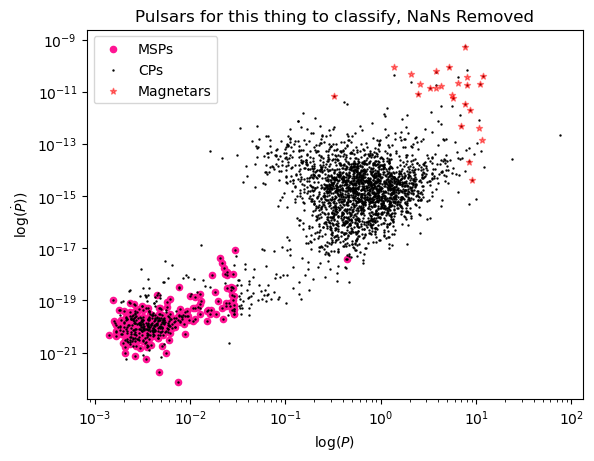

In [41]:
print(f'Number of MSPs: {psrs.P0[psrs_msp].shape}')

fig = plt.figure()
ax = plt.gca()
ax.scatter(psrs.P0[psrs_msp], psrs.P1[psrs_msp], s=20, color='deeppink', label='MSPs')
ax.scatter(psrs.P0, psrs.P1, s=0.5, color='black', label='CPs')
ax.scatter(mags.Period, mags.Pdot, s=20, alpha=0.5, color='red', marker='*', label='Magnetars')
ax.set_yscale('log')
ax.set_xscale('log')
ax.legend()
ax.set_xlabel(r'$\log(P)$')
ax.set_ylabel(r'$\log(\dot{P}))$')
ax.set_title('Pulsars for this thing to classify, NaNs Removed');

## Prepare a Training Dataset

In [42]:
# define features
# params = ['P0', 'P1']
params = ['logP0', 'logP1', 'AGE', 'EDOT', 'BSURF']
X = np.array(psrs[params])

# classify
y = psrs_msp.astype(int)

# masks for each class to split rows into members and nonmebers
msp_mask = y ==1
non_mask = y == 0

print(f'X.shape: {X.shape}\ny.shape: {y.shape}')

X.shape: (2800, 5)
y.shape: (2800,)


In [43]:
# split feature arrays by class
X_msp = np.array(X[psrs_msp]) # all features for M4 stars
y_msp = np.array(y[psrs_msp]) # all features for non-M4 stars
X_non = np.array(X[non_mask]) # corresponding labels
y_non = np.array(y[non_mask])

n = X_msp.shape[0]
idx = np.random.choice(X_non.shape[0], size=n, replace=False)
X_non = X_non[idx]
y_non = y_non[idx]

X = np.concatenate((X_msp, X_non))
y = np.concatenate((y_msp, y_non))

print(f'X.shape: {X.shape}\ny.shape: {y.shape}')

X.shape: (634, 5)
y.shape: (634,)


## Logistical Regression

In [62]:
from sklearn.model_selection import train_test_split
# hannah said to do this and I beleive her
indices = np.arange(X.shape[0])
X_train, X_tst, y_train, y_tst, train_idx, tst_idx = train_test_split(X, y, indices, test_size=0.2, shuffle=True, random_state=42)

In [63]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_tst_scaled = scaler.fit_transform(X_tst)

In [64]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(class_weight='balanced', random_state=42)
model.fit(X_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,42
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [65]:
# Predict classes
y_pred = model.predict(X_tst_scaled)

# Predict probabilities (optional)
y_prob = model.predict_proba(X_tst_scaled)[:, 1]  # probability of MSP

In [66]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Basic accuracy
print("Accuracy:", accuracy_score(y_tst, y_pred))

# Confusion matrix
print("Confusion matrix:\n", confusion_matrix(y_tst, y_pred))

# Full classification report
print(classification_report(y_tst, y_pred))

Accuracy: 0.984251968503937
Confusion matrix:
 [[60  1]
 [ 1 65]]
              precision    recall  f1-score   support

           0       0.98      0.98      0.98        61
           1       0.98      0.98      0.98        66

    accuracy                           0.98       127
   macro avg       0.98      0.98      0.98       127
weighted avg       0.98      0.98      0.98       127



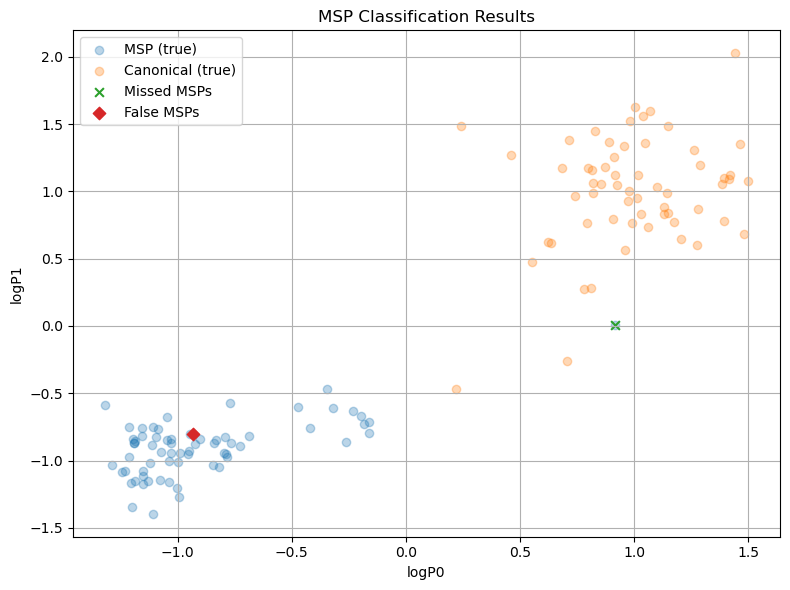

In [67]:
# Choose 2 features to plot
xcol = 'logP0'
ycol = 'logP1'

# Build DataFrame for easy masking
tst_df = pd.DataFrame(X_tst_scaled, columns=params)
tst_df['true'] = y_tst
tst_df['pred'] = y_pred

# Masks
msp_true = tst_df['true'] == 1

canon_true = tst_df['true'] == 0

correct = tst_df['true'] == tst_df['pred']
incorrect = ~correct

false_msp = incorrect & (tst_df['pred'] == 1) 

missed_msp = incorrect & (tst_df['true'] == 1)  


plt.figure(figsize=(8,6))

# True MSPs
plt.scatter(tst_df.loc[msp_true, xcol],tst_df.loc[msp_true, ycol],alpha=0.3,label="MSP (true)")

# True canonical pulsars
plt.scatter(tst_df.loc[canon_true, xcol],tst_df.loc[canon_true, ycol],alpha=0.3,label="Canonical (true)")

# Missed MSPs
plt.scatter(tst_df.loc[missed_msp, xcol],tst_df.loc[missed_msp, ycol],s=40,label="Missed MSPs",marker="x")

# Falsly Flagged MSPs
plt.scatter(tst_df.loc[false_msp, xcol],tst_df.loc[false_msp, ycol],s=40,label="False MSPs",marker="D")

plt.xlabel(xcol)
plt.ylabel(ycol)
plt.title("MSP Classification Results")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## Neural Network

Some repitiion will be present for clenaliness

In [80]:
# define features
params = ['logP0', 'logP1', 'AGE', 'EDOT', 'BSURF']
X = np.array(psrs[params])

# classify
y = psrs_msp.astype(int)

# masks for each class to split rows into members and nonmebers
msp_mask = y ==1
non_mask = y == 0

print(f'X.shape: {X.shape}\ny.shape: {y.shape}')

X.shape: (2800, 5)
y.shape: (2800,)


In [81]:


# split feature arrays by class
X_msp = np.array(X[psrs_msp]) # all features for M4 stars
y_msp = np.array(y[psrs_msp]) # all features for non-M4 stars
X_non = np.array(X[non_mask]) # corresponding labels
y_non = np.array(y[non_mask])

n = X_msp.shape[0]
idx = np.random.choice(X_non.shape[0], size=n, replace=False)
X_non = X_non[idx]
y_non = y_non[idx]

X = np.concatenate((X_msp, X_non))
y = np.concatenate((y_msp, y_non))

print(f'X.shape: {X.shape}\ny.shape: {y.shape}')

X.shape: (634, 5)
y.shape: (634,)


In [82]:
indices = np.arange(X.shape[0])
X_train, X_tst, y_train, y_tst, train_idx, test_idx = train_test_split(X, y, indices, test_size=0.1, shuffle=True, random_state=42)

In [83]:
transformer = StandardScaler()

X_train = transformer.fit_transform(X_train)
X_tst = transformer.fit_transform(X_tst)

# make some arrays
X_train = jnp.array(X_train)
X_tst = jnp.array(X_tst)
y_train = jnp.array(y_train)
y_tst = jnp.array(y_tst)

# Data batching!!
batch_size = 64
n_batches = X_train.shape[0] // batch_size

X_train = X_train[:n_batches * batch_size].reshape((n_batches, batch_size, *X_train.shape[1:]))
y_train = y_train[:n_batches * batch_size].reshape((n_batches, batch_size, *y_train.shape[1:]))
X_train.shape, y_train.shape

((8, 64, 5), (8, 64))

In [89]:
### TIME FOR MODEL TRAINING

n_classes = 2

class DenseClassifier(nn.Module):
    """A simple dense classifier."""

    @nn.compact
    def __call__(self, x):
        x = nn.Dense(10)(x)
        x = nn.relu(x)
        x = nn.Dense(10)(x)
        x = nn.relu(x)
        x = nn.Dense(n_classes)(x)
        x = nn.relu(x)
        x = nn.Dense(n_classes)(x)
        x = nn.relu(x)
        x = nn.Dense(n_classes)(x)
        return x

dummy_input = jnp.ones((1, 5))
dnn = DenseClassifier()
print(dnn.tabulate(jax.random.PRNGKey(0), dummy_input))


                            DenseClassifier Summary                             
┏━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┓
┃ path    ┃ module          ┃ inputs        ┃ outputs       ┃ params           ┃
┡━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━┩
│         │ DenseClassifier │ float32[1,5]  │ float32[1,2]  │                  │
├─────────┼─────────────────┼───────────────┼───────────────┼──────────────────┤
│ Dense_0 │ Dense           │ float32[1,5]  │ float32[1,10] │ bias:            │
│         │                 │               │               │ float32[10]      │
│         │                 │               │               │ kernel:          │
│         │                 │               │               │ float32[5,10]    │
│         │                 │               │               │                  │
│         │                 │               │               │ 60 (240 B)       │
├─────────┼────────────────

In [90]:
@struct.dataclass
class Metrics(metrics.Collection):
    accuracy: metrics.Accuracy
    loss: metrics.Average.from_output('loss')

class TrainState(train_state.TrainState):
   metrics: Metrics

def create_train_state(model, rng, learning_rate):
    params = model.init(rng, dummy_input)['params']
    tx = optax.adam(learning_rate)
    return TrainState.create(
        apply_fn=model.apply, params=params, tx=tx,
        metrics=Metrics.empty())

@jax.jit
def train_step(state, batch, label):
  """Train for a single step."""
  def loss_fn(params):
    logits = state.apply_fn({'params': params}, batch)
    loss = optax.softmax_cross_entropy_with_integer_labels(
        logits=logits, labels=label).mean()
    return loss
  grad_fn = jax.grad(loss_fn)
  grads = grad_fn(state.params)
  state = state.apply_gradients(grads=grads)
  return state

@jax.jit
def compute_metrics(*, state, batch, label):
    logits = state.apply_fn({'params': state.params}, batch)
    loss = optax.softmax_cross_entropy_with_integer_labels(
        logits=logits, labels=label).mean()
    metric_updates = state.metrics.single_from_model_output(
        logits=logits, labels=label, loss=loss)
    metrics = state.metrics.merge(metric_updates)
    state = state.replace(metrics=metrics)
    return state

init_rng = jax.random.PRNGKey(0)

learning_rate = 0.01

state = create_train_state(dnn, init_rng, learning_rate)
del init_rng  # Must not be used anymore.

metrics_history = {'train_loss': [],
                   'train_accuracy': [],
                   'test_loss': [],
                   'test_accuracy': []}

In [91]:
n_epochs = 50

step = 0

for _ in range(n_epochs):
  for batch, label in zip(X_train, y_train):

    # Run optimization steps over training batches and compute batch metrics
    state = train_step(state, batch, label) # get updated train state (which contains the updated parameters)
    state = compute_metrics(state=state, batch=batch, label=label) # aggregate batch metrics

    if (step+1) % n_batches == 0: # one training epoch has passed
      for metric,value in state.metrics.compute().items(): # compute metrics
        metrics_history[f'train_{metric}'].append(value) # record metrics
      state = state.replace(metrics=state.metrics.empty()) # reset train_metrics for next training epoch

      # Compute metrics on the test set after each training epoch
      test_state = state
      test_state = compute_metrics(state=test_state, batch=X_tst, label=y_tst)

      for metric,value in test_state.metrics.compute().items():
        metrics_history[f'test_{metric}'].append(value)

      print(f"train epoch: {(step+1) // n_batches}, "
            f"loss: {metrics_history['train_loss'][-1]}, "
            f"accuracy: {metrics_history['train_accuracy'][-1] * 100}")
      print(f"test epoch: {(step+1) // n_batches}, "
            f"loss: {metrics_history['test_loss'][-1]}, "
            f"accuracy: {metrics_history['test_accuracy'][-1] * 100}")
    step += 1
  

train epoch: 1, loss: 0.5971736907958984, accuracy: 97.4609375
test epoch: 1, loss: 0.5157128572463989, accuracy: 96.875
train epoch: 2, loss: 0.4395933747291565, accuracy: 97.8515625
test epoch: 2, loss: 0.36588677763938904, accuracy: 96.875
train epoch: 3, loss: 0.3100060820579529, accuracy: 98.046875
test epoch: 3, loss: 0.3070112466812134, accuracy: 98.4375
train epoch: 4, loss: 0.25386038422584534, accuracy: 98.046875
test epoch: 4, loss: 0.2994178831577301, accuracy: 98.4375
train epoch: 5, loss: 0.22175905108451843, accuracy: 98.046875
test epoch: 5, loss: 0.2896243929862976, accuracy: 98.4375
train epoch: 6, loss: 0.19580593705177307, accuracy: 98.046875
test epoch: 6, loss: 0.2763221263885498, accuracy: 98.4375
train epoch: 7, loss: 0.17452828586101532, accuracy: 98.046875
test epoch: 7, loss: 0.26533621549606323, accuracy: 98.4375
train epoch: 8, loss: 0.15904617309570312, accuracy: 98.046875
test epoch: 8, loss: 0.24755825102329254, accuracy: 98.4375
train epoch: 9, loss: 0.

In [92]:
print('Mean training accuracy: %.3f' % np.mean(metrics_history['train_accuracy']))
print('Mean testing accuracy: %.3f' % np.mean(metrics_history['test_accuracy']))

Mean training accuracy: 0.983
Mean testing accuracy: 0.984


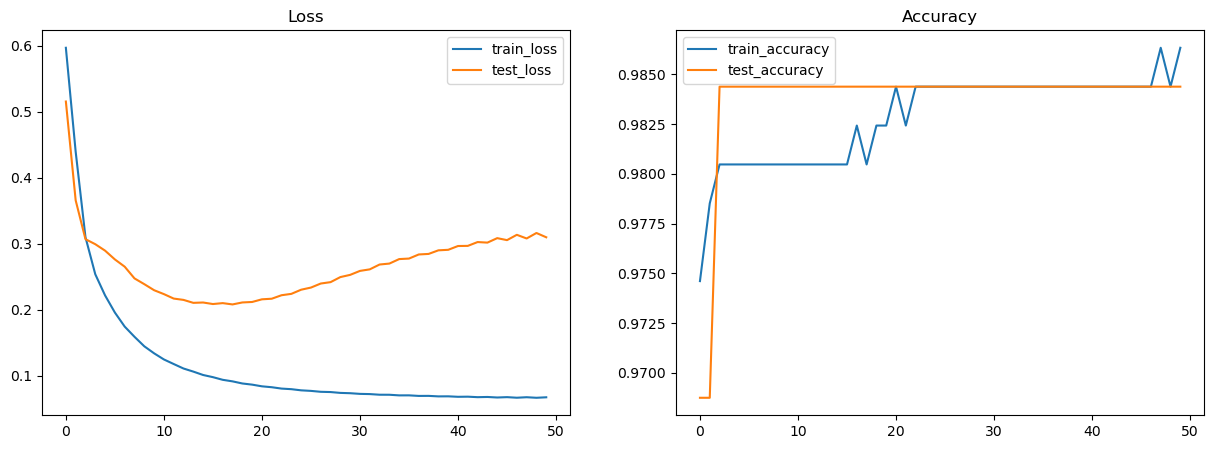

<Figure size 640x480 with 0 Axes>

In [93]:
# Plot loss and accuracy in subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
ax1.set_title('Loss')
ax2.set_title('Accuracy')
for dataset in ('train','test'):
  ax1.plot(metrics_history[f'{dataset}_loss'], label=f'{dataset}_loss')
  ax2.plot(metrics_history[f'{dataset}_accuracy'], label=f'{dataset}_accuracy')
ax1.legend()
ax2.legend()
plt.show()
plt.clf();

In [94]:
@jax.jit
def pred_step(state, batch):
  logits = state.apply_fn({'params': state.params}, batch)
  return logits.argmax(axis=1)

pred = pred_step(state, X_tst)
pred

Array([0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0,
       1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1,
       1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0],      dtype=int32)

(array([32.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0., 32.]),
 array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ]),
 <BarContainer object of 10 artists>)

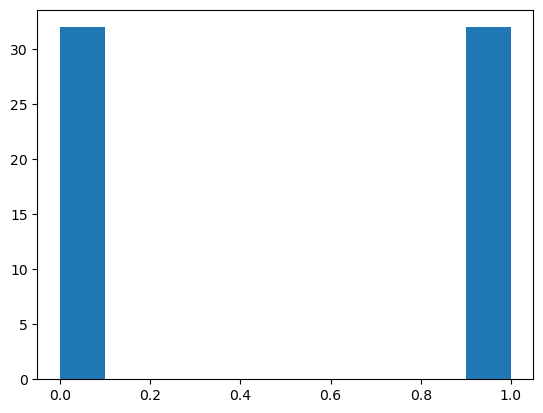

In [95]:
plt.hist(pred)

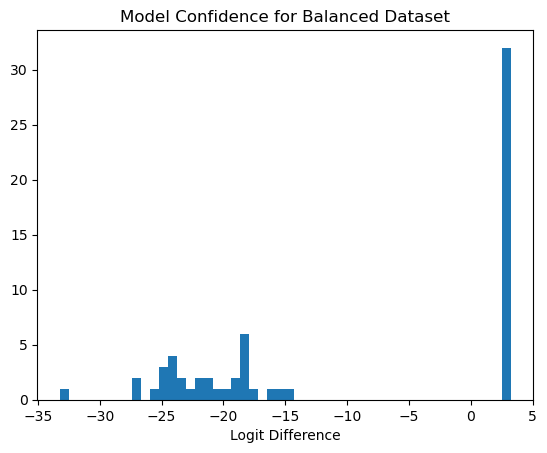

In [96]:
outputs = state.apply_fn({'params': state.params}, X_tst)
plt.hist(jnp.diff(outputs, axis=1).flatten(), bins=50)
plt.title('Model Confidence for Balanced Dataset')
plt.xlabel('Logit Difference');